# Introduction to Retrieval Augmented Generation with S&P 500 news

In this notebook, you will explore how to build a simple Retrieval-Augmented Generation (RAG) pipeline using financial news articles from S&P 500 companies.

We'll start by vectorizing text data, creating a vector store using FAISS, and integrating it with OpenAI's GPT models to answer questions using retrieved information.

This workflow emulates real-world systems in finance where natural language data (news, filings, analyst reports) are used to support decision-making.

# 📌 Objectives

By the end of this notebook, students will be able to:

1. **Perform Semantic Search with Metadata Filtering:**
   - Query the provided FAISS vector store to retrieve relevant financial news articles based on natural language questions.
   - Apply optional filters using metadata such as ticker or publication date to refine search results.

2. **Enrich Data with Company Metadata:**
   - Use the `yfinance` library to retrieve company-level metadata (company name, sector, industry) for tickers in the dataset.
   - Integrate this metadata to support enhanced filtering and analysis of news data.

3. **Build a Retrieval-Augmented Generation (RAG) Pipeline:**
   - Combine retrieved news snippets as context to generate answers using OpenAI’s GPT models.
   - Construct effective prompts that guide the language model to provide concise, context-aware responses.

4. **Evaluate and Analyze RAG Outputs:**
   - Review generated answers alongside the supporting news excerpts.
   - Reflect on the strengths and limitations of the simple RAG pipeline and consider potential improvements, such as adding more filters or refining retrieval strategies.

5. **Incorporate Financial Metadata into Retrieval Context:**
   - Enrich retrieved news snippets with key financial metadata including ticker, company name, sector, and industry.
   - Format prompts that combine both text excerpts and metadata to provide richer context to the language model.

6. **Generate Context-Aware Answers Using OpenAI Models:**
   - Construct and send prompts to an LLM that leverage both news content and metadata to produce concise, informed financial analysis.

7. **Compare Answers With and Without Metadata:**
   - Evaluate the impact of including financial metadata on answer quality using criteria such as clarity, detail, accuracy, and contextual relevance.
   - Summarize findings to reflect on the role of metadata in improving retrieval-augmented generation.

## Install and Import important librairies

First, we install and import the necessary libraries for:
- Text embedding generation (sentence-transformers)
- Efficient similarity search (faiss)
- Data manipulation (pandas, numpy)
- Visualization (matplotlib)

> ℹ️ FAISS uses inner product for cosine similarity by normalizing vectors.

In [1]:
%pip install sentence-transformers
%pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 45.2 MB/s eta 0:00:00


In [2]:
from sentence_transformers import SentenceTransformer
import faiss
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
import matplotlib.pyplot as plt
import faiss

## Load news data
We load a CSV file of financial news, focusing on TITLE and SUMMARY, along with metadata like TICKER and PUBLICATION_DATE.
These will be embedded into vectors and used for semantic retrieval.

In [3]:
K = 25

In [5]:
df_news = pd.read_csv('df_news.csv')
df_news['PUBLICATION_DATE'] = pd.to_datetime(df_news['PUBLICATION_DATE']).dt.date
display(df_news)

,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...
...,...,...,...,...,...,...
4866,ZTS,2 Dividend Stocks to Buy With $500 and Hold Fo...,Zoetis is a leading animal health company with...,2025-05-23,Motley Fool,https://www.fool.com/investing/2025/05/23/2-di...
4867,ZTS,Zoetis (NYSE:ZTS) Declares US$0.50 Dividend Pe...,Zoetis (NYSE:ZTS) recently affirmed a dividend...,2025-05-22,Simply Wall St.,https://finance.yahoo.com/news/zoetis-nyse-zts...
4868,ZTS,Jim Cramer on Zoetis (ZTS): “It Does Seem to B...,We recently published a list of Jim Cramer Tal...,2025-05-21,Insider Monkey,https://finance.yahoo.com/news/jim-cramer-zoet...
4869,ZTS,Zoetis (ZTS) Upgraded to Buy: Here's Why,Zoetis (ZTS) might move higher on growing opti...,2025-05-21,Zacks,https://finance.yahoo.com/news/zoetis-zts-upgr...


In [6]:
df_news['EMBEDDED_TEXT'] = df_news['TITLE'] + ' : ' + df_news['SUMMARY']

In [7]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## Implement FAISS vector store
We:
- Use a pre-trained sentence transformer (all-MiniLM-L6-v2) to embed documents.
- Normalize vectors to use cosine similarity.
- Create a FAISS index and implement a basic search function.

This will allow us to retrieve relevant news snippets given a natural language question.


In [8]:
# Load model and compute embeddings
text_embeddings = model.encode(df_news['EMBEDDED_TEXT'].tolist(), convert_to_numpy=True)

# Normalize embeddings to use cosine similarity (via inner product in FAISS)
text_embeddings = text_embeddings / np.linalg.norm(text_embeddings, axis=1, keepdims=True)

# Prepare metadata
documents = df_news['EMBEDDED_TEXT'].tolist()
metadata = [
    {
        'PUBLICATION_DATE': row['PUBLICATION_DATE'],
        'TICKER': row['TICKER'],
        'PROVIDER': row['PROVIDER']
    }
    for _, row in df_news.iterrows()
]

In [9]:
embedding_dim = text_embeddings.shape[1]
faiss_index = faiss.IndexFlatIP(embedding_dim)  # Cosine similarity via inner product
faiss_index.add(text_embeddings)

In [10]:
class FaissVectorStore:
    def __init__(self, model, index, embeddings, documents, metadata):
        self.model = model
        self.index = index
        self.embeddings = embeddings
        self.documents = documents
        self.metadata = metadata

    def search(self, query, k=5, metadata_filter=None):
        query_embedding = self.model.encode([query])
        query_embedding = query_embedding / np.linalg.norm(query_embedding)

        if metadata_filter:
            filtered_indices = [i for i, meta in enumerate(self.metadata) if metadata_filter(meta)]
            if not filtered_indices:
                return []
            k = min(k, len(filtered_indices))  # avoid FAISS returning -1 indices
            filtered_embeddings = self.embeddings[filtered_indices]
            temp_index = faiss.IndexFlatIP(filtered_embeddings.shape[1])
            temp_index.add(filtered_embeddings)
            D, I = temp_index.search(query_embedding, k)
            indices = [filtered_indices[i] for i in I[0]]
            D = D[0]  # keep similarities 1-D, same as the unfiltered branch
        else:
            D, I = self.index.search(query_embedding, k)
            indices = I[0]
            D = D[0]

        results = []
        for idx, sim in zip(indices, D):
            results.append((self.documents[idx], self.metadata[idx], float(sim)))
        return results

In [11]:
# Create FAISS-based store
faiss_store = FaissVectorStore(
    model=model,
    index=faiss_index,
    embeddings=text_embeddings,
    documents=documents,
    metadata=metadata
)

### Setup OpenAI Client

👉 **Instructions**:
- Import the `OpenAI` client from the `openai` Python library.
- You will need an **OpenAI API key** to use their models programmatically:
  - Go to [https://platform.openai.com/](https://platform.openai.com/) and sign up or log in.
  - Create an API key from your [API keys dashboard](https://platform.openai.com/account/api-keys).
  - ⚠️ **Keep your API key private** and **do not** share or hardcode it in public notebooks.
- Note that **usage of the OpenAI API is not free**. You will need to:
  - Add a payment method.
  - Monitor your usage to avoid unexpected charges.
  - Optionally set usage limits from your account settings.
- You can refer to the **course’s Study Resources** for a step-by-step guide on creating an OpenAI account and retrieving your API key.

Then:
- Initialize the client with `OpenAI(api_key="YOUR_KEY_HERE")`.
- Send a test request using `.responses.create()` and the `"gpt-4o-mini"` model with a simple prompt:

  ```python
  response = client.responses.create(
      model="gpt-4o-mini",
      input="Write a one-sentence bedtime story about a unicorn."
  )
  print(response.output_text)


In [12]:
import os
from getpass import getpass
from openai import OpenAI

# Load the API key WITHOUT hardcoding it in the notebook:
#  1. Google Colab -> add a secret named OPENAI_API_KEY (key icon in the left sidebar)
#  2. Local run    -> export the OPENAI_API_KEY environment variable
#  3. Fallback     -> interactive prompt (the key is never displayed nor stored)
api_key = None
try:
    from google.colab import userdata
    api_key = userdata.get('OPENAI_API_KEY')
except Exception:
    api_key = os.environ.get('OPENAI_API_KEY')

if not api_key:
    api_key = getpass('Enter your OpenAI API key: ')

client = OpenAI(api_key=api_key)
print('OpenAI client initialized.')

Enter your OpenAI API key: ··········
OpenAI client initialized.


In [14]:
# Send a test request to verify the client is correctly configured
response = client.responses.create(
    model="gpt-4o-mini",
    input="Write a one-sentence bedtime story about a unicorn."
)
print(response.output_text)

Under a sky filled with twinkling stars, a lonely unicorn discovered a hidden glen where the gentle whispers of the moonlit flowers sang sweet lullabies, lulling her into a peaceful slumber surrounded by shimmering dreams.


## Retrieve Additional Metadata from Yahoo Finance

👉 **Instructions**:
- We will enrich our news dataset by retrieving **company-level metadata** using the `yfinance` library.
- The goal is to map each unique stock ticker (`TICKER`) in the dataset to:
  - `COMPANY_NAME`
  - `SECTOR`
  - `INDUSTRY`

> ℹ️ `yfinance` fetches live data from Yahoo Finance. If you're running this in a cloud environment or during peak hours, expect some tickers to fail or rate limits to apply.

✅ After this step, you will have a new DataFrame (e.g. `df_meta`) with the columns `TICKER`, `COMPANY_NAME`, `SECTOR`, `INDUSTRY` that maps tickers to their company names, sectors, and industries. This metadata will be useful later to add filters and analysis based on sector or industry categories.


In [15]:
%pip install yfinance

In [16]:
import yfinance as yf
import time


def get_ticker_metadata(ticker: str) -> dict:
    """Fetch company name, sector and industry for a single ticker from Yahoo Finance."""
    info = yf.Ticker(ticker).info
    return {
        'TICKER': ticker,
        'COMPANY_NAME': info.get('longName') or info.get('shortName'),
        'SECTOR': info.get('sector'),
        'INDUSTRY': info.get('industry'),
    }


def fetch_company_metadata(tickers: list) -> pd.DataFrame:
    """Fetch metadata for every ticker, with one retry round for transient failures."""
    records, failed = [], []
    for i, ticker in enumerate(tickers, start=1):
        try:
            records.append(get_ticker_metadata(ticker))
        except Exception:
            failed.append(ticker)
        if i % 100 == 0:
            print(f'  processed {i}/{len(tickers)} tickers...')
    # Retry once: most failures are transient Yahoo Finance rate limits
    for ticker in list(failed):
        try:
            time.sleep(1)
            records.append(get_ticker_metadata(ticker))
            failed.remove(ticker)
        except Exception:
            pass
    if failed:
        print(f'WARNING: could not retrieve metadata for {len(failed)} tickers: {failed}')
    return pd.DataFrame(records)


unique_tickers = sorted(df_news['TICKER'].unique())
print(f'Fetching metadata for {len(unique_tickers)} unique tickers from Yahoo Finance...')

# Cache the result locally so re-running the notebook does not hammer Yahoo Finance
if os.path.exists('df_meta.csv'):
    df_meta = pd.read_csv('df_meta.csv')
    print('Loaded company metadata from local cache (df_meta.csv).')
else:
    df_meta = fetch_company_metadata(unique_tickers)
    df_meta.to_csv('df_meta.csv', index=False)

# Fill any gaps so downstream prompts never receive NaN
for col in ['COMPANY_NAME', 'SECTOR', 'INDUSTRY']:
    df_meta[col] = df_meta[col].fillna('Unknown')

display(df_meta)

Fetching metadata for 490 unique tickers from Yahoo Finance...
Loaded company metadata from local cache (df_meta.csv).


,TICKER,COMPANY_NAME,SECTOR,INDUSTRY
0,A,"Agilent Technologies, Inc.",Healthcare,Diagnostics & Research
1,AAPL,Apple Inc.,Technology,Consumer Electronics
2,ABBV,AbbVie Inc.,Healthcare,Drug Manufacturers - General
3,ABNB,"Airbnb, Inc.",Consumer Cyclical,Travel Services
4,ABT,Abbott Laboratories,Healthcare,Medical Devices
...,...,...,...,...
485,XOM,ExxonMobil Holdings Corporation,Energy,Oil & Gas Integrated
486,XYL,Xylem Inc.,Industrials,Specialty Industrial Machinery
487,YUM,"Yum! Brands, Inc.",Consumer Cyclical,Restaurants
488,ZBH,"Zimmer Biomet Holdings, Inc.",Healthcare,Medical Devices


In [17]:
# Manual fallback for tickers Yahoo Finance no longer serves (companies that were
# acquired, taken private or delisted after the news window of May 2025):
#   WBA -> taken private (Sycamore), K -> acquired by Mars, ANSS -> acquired by Synopsys,
#   IPG -> acquired by Omnicom, DAY -> acquired by Thoma Bravo; the rest are
#   occasional Yahoo 404s. Values come from the companies' last public profiles.
FALLBACK_METADATA = {
    'ANSS': ('ANSYS, Inc.', 'Technology', 'Software - Application'),
    'BK':   ('The Bank of New York Mellon Corporation', 'Financial Services', 'Banks - Diversified'),
    'CTRA': ('Coterra Energy Inc.', 'Energy', 'Oil & Gas Exploration & Production'),
    'DAY':  ('Dayforce, Inc.', 'Technology', 'Software - Application'),
    'FI':   ('Fiserv, Inc.', 'Technology', 'Information Technology Services'),
    'IPG':  ('The Interpublic Group of Companies, Inc.', 'Communication Services', 'Advertising Agencies'),
    'K':    ('Kellanova', 'Consumer Defensive', 'Packaged Foods'),
    'WBA':  ('Walgreens Boots Alliance, Inc.', 'Healthcare', 'Pharmaceutical Retailers'),
}

missing = sorted(set(unique_tickers) - set(df_meta['TICKER']))
recovered = [
    {'TICKER': t, 'COMPANY_NAME': FALLBACK_METADATA[t][0],
     'SECTOR': FALLBACK_METADATA[t][1], 'INDUSTRY': FALLBACK_METADATA[t][2]}
    for t in missing if t in FALLBACK_METADATA
]
if recovered:
    df_meta = pd.concat([df_meta, pd.DataFrame(recovered)], ignore_index=True)
    df_meta = df_meta.sort_values('TICKER').reset_index(drop=True)
    df_meta.to_csv('df_meta.csv', index=False)

print(f'Tickers recovered via manual fallback: {[r["TICKER"] for r in recovered]}')
print(f'Metadata coverage: {df_meta["TICKER"].nunique()} / {len(unique_tickers)} tickers')

Tickers recovered via manual fallback: []
Metadata coverage: 490 / 490 tickers


In [18]:
# Merge the company metadata into the news DataFrame (left join on TICKER)
df_news = df_news.merge(df_meta, on='TICKER', how='left')
for col in ['COMPANY_NAME', 'SECTOR', 'INDUSTRY']:
    df_news[col] = df_news[col].fillna('Unknown')

covered = (df_news['SECTOR'] != 'Unknown').sum()
print(f'News rows with sector metadata: {covered} / {len(df_news)}')
display(df_news.head(10))

News rows with sector metadata: 4761 / 4871


,TICKER,TITLE,SUMMARY,PUBLICATION_DATE,PROVIDER,URL,EMBEDDED_TEXT,COMPANY_NAME,SECTOR,INDUSTRY
0,MMM,2 Dow Jones Stocks with Promising Prospects an...,The Dow Jones (^DJI) is made up of 30 of the m...,2025-05-29,StockStory,https://finance.yahoo.com/news/2-dow-jones-sto...,2 Dow Jones Stocks with Promising Prospects an...,3M Company,Industrials,Conglomerates
1,MMM,3 S&P 500 Stocks Skating on Thin Ice,The S&P 500 (^GSPC) is often seen as a benchma...,2025-05-27,StockStory,https://finance.yahoo.com/news/3-p-500-stocks-...,3 S&P 500 Stocks Skating on Thin Ice : The S&P...,3M Company,Industrials,Conglomerates
2,MMM,3M Rises 15.8% YTD: Should You Buy the Stock N...,"MMM is making strides in the aerospace, indust...",2025-05-22,Zacks,https://finance.yahoo.com/news/3m-rises-15-8-y...,3M Rises 15.8% YTD: Should You Buy the Stock N...,3M Company,Industrials,Conglomerates
3,MMM,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,Quarterly earnings results are a good time to ...,2025-05-22,StockStory,https://finance.yahoo.com/news/q1-earnings-rou...,Q1 Earnings Roundup: 3M (NYSE:MMM) And The Res...,3M Company,Industrials,Conglomerates
4,MMM,3 Cash-Producing Stocks with Questionable Fund...,While strong cash flow is a key indicator of s...,2025-05-19,StockStory,https://finance.yahoo.com/news/3-cash-producin...,3 Cash-Producing Stocks with Questionable Fund...,3M Company,Industrials,Conglomerates
5,MMM,Here's Why You Should Retain 3M Stock in Your ...,MMM benefits from strength in its business seg...,2025-05-15,Zacks,https://finance.yahoo.com/news/heres-why-retai...,Here's Why You Should Retain 3M Stock in Your ...,3M Company,Industrials,Conglomerates
6,MMM,"3M Co: A company with a sound balance sheet, a...",R&D spending as a percentage of sales has rema...,2025-05-13,GuruFocus.com,https://finance.yahoo.com/news/3m-co-company-s...,"3M Co: A company with a sound balance sheet, a...",3M Company,Industrials,Conglomerates
7,MMM,"Rogers, Enviri, 3M, Gates Industrial Corporati...",A number of stocks jumped in the afternoon ses...,2025-05-12,StockStory,https://finance.yahoo.com/news/rogers-enviri-3...,"Rogers, Enviri, 3M, Gates Industrial Corporati...",3M Company,Industrials,Conglomerates
8,MMM,"3 ""Top Picks"" From Wall Street That Are Magnif...",Another is a building products and controls co...,2025-05-10,Motley Fool,https://www.fool.com/investing/2025/05/10/3-to...,"3 ""Top Picks"" From Wall Street That Are Magnif...",3M Company,Industrials,Conglomerates
9,MMM,3M vs. Honeywell: Which Industrial Conglomerat...,Amid a strong foothold in the diversified oper...,2025-05-08,Zacks,https://finance.yahoo.com/news/3m-vs-honeywell...,3M vs. Honeywell: Which Industrial Conglomerat...,3M Company,Industrials,Conglomerates


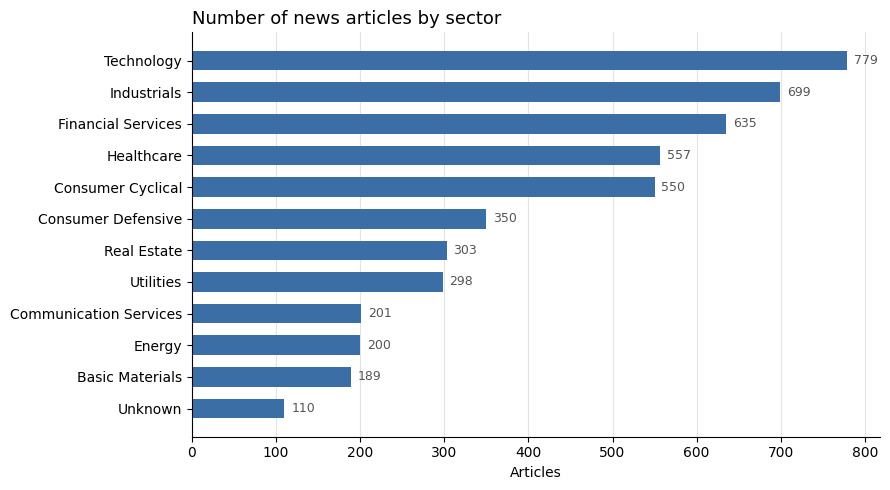

In [19]:
# Quick look at how the news dataset is distributed across sectors
sector_counts = df_news['SECTOR'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(sector_counts.index, sector_counts.values, color='#3B6EA5', height=0.62)
ax.set_title('Number of news articles by sector', loc='left', fontsize=13)
ax.set_xlabel('Articles')
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, color='#E3E3E3', linewidth=0.8)
ax.set_axisbelow(True)
for y, v in enumerate(sector_counts.values):
    ax.text(v + 8, y, str(v), va='center', fontsize=9, color='#555555')
plt.tight_layout()
plt.show()

## Retrieval-Augmented Generation (RAG): Retrieve Documents and Generate Answers

👉 **Instructions**:

In this part of the assignment, your task is to build a simple Retrieval-Augmented Generation (RAG) pipeline that:

- Takes a user question as input.
- Searches the FAISS vector store to find a set of relevant financial news articles based on semantic similarity.
- Uses the retrieved news articles as context to generate a clear, concise answer to the question by interacting with the OpenAI language model.
- Returns both the generated answer and the underlying news snippets used for context.

### What you need to focus on:

- Implement a retrieval mechanism to query your vector store and obtain the top relevant documents for any question.
- Construct prompts that effectively combine retrieved news content with the user’s question to guide the language model’s response.
- Use the OpenAI API to generate answers grounded in the retrieved context.
- Organize the outputs so that for each question, you have:
  - The generated answer.
  - The collection of news excerpts used to produce that answer.

### What you will be provided:

- Helper functions to display outputs in markdown format.
- Lists of example questions covering topics, companies, and industries to test your implementation.

---

Your solution can take any form or structure you find appropriate, as long as it fulfills these core objectives. This exercise will give you hands-on experience with integrating retrieval and generation for practical applications in finance.


#### Print markdown
You can use the following function to print answers from GPT4o-mini in markdown.

In [20]:
from IPython.display import Markdown, display

def print_markdown(text):
    display(Markdown(text))

#### Predefined questions

In [21]:
questions_topic = [
"What are the major concerns expressed in financial news about inflation?",
"How is investor sentiment described in recent financial headlines?",
"What role is artificial intelligence playing in recent finance-related news stories?"
]

questions_company = [
"How is Microsoft being portrayed in news stories about artificial intelligence?",
"What financial news headlines connect Amazon with automation or logistics?"
]

questions_industry = [
"What are the main themes emerging in financial news about the semiconductor industry?",
"What trends are being reported in the retail industry?",
"What risks or challenges are discussed in recent news about the energy industry?"
]

In [22]:
def retrieve(question: str, k: int = K, metadata_filter=None) -> list:
    """Retrieve the k most semantically similar news snippets for a question."""
    return faiss_store.search(question, k=k, metadata_filter=metadata_filter)


def generate_answer(prompt: str, model: str = 'gpt-4o-mini') -> str:
    """Send a prompt to the OpenAI model and return the generated text."""
    response = client.responses.create(model=model, input=prompt)
    return response.output_text


def build_prompt(question: str, docs: list) -> str:
    """Combine the retrieved news snippets (text only, no metadata) with the question."""
    context = "\n\n".join(
        f"[{i}] {text}" for i, (text, meta, sim) in enumerate(docs, start=1)
    )
    return f"""You are a financial analyst assistant.
Answer the user's question using ONLY the information contained in the news excerpts below.
Be concise (one or two paragraphs), synthesize across excerpts, and do not state facts
that are not supported by the context. If the context is insufficient, say so explicitly.

News excerpts:
{context}

Question: {question}

Answer:"""


def rag_answer(question: str, k: int = K, metadata_filter=None):
    """Full RAG pipeline v1: retrieve -> build prompt -> generate. Returns (answer, docs)."""
    docs = retrieve(question, k=k, metadata_filter=metadata_filter)
    answer = generate_answer(build_prompt(question, docs))
    return answer, docs

In [23]:
def display_rag_result(question: str, answer: str, docs: list, n_show: int = 5) -> None:
    """Render the generated answer plus the top retrieved snippets in markdown."""
    lines = [f"### ❓ {question}", "", "**🧠 Generated answer:**", "", answer, "",
             f"**📰 Top {n_show} of {len(docs)} retrieved snippets used as context:**", ""]
    for i, (text, meta, sim) in enumerate(docs[:n_show], start=1):
        snippet = text if len(text) <= 280 else text[:280] + '…'
        lines.append(
            f"> **[{i}]** `{meta['TICKER']}` · {meta['PUBLICATION_DATE']} · "
            f"{meta['PROVIDER']} · similarity = {sim:.3f}  \n> {snippet}"
        )
        lines.append("")
    print_markdown("\n".join(lines))

In [24]:
# Example of metadata filtering supported by the vector store:
# restrict retrieval to Microsoft (MSFT) news published on/after May 1, 2025
from datetime import date

msft_filter = lambda meta: meta['TICKER'] == 'MSFT' and meta['PUBLICATION_DATE'] >= date(2025, 5, 1)

filtered = retrieve("How is Microsoft investing in artificial intelligence?", k=5,
                    metadata_filter=msft_filter)
for text, meta, sim in filtered:
    print(f"({meta['TICKER']}, {meta['PUBLICATION_DATE']}, sim={sim:.3f}) {text[:110]}…")

(MSFT, 2025-05-30, sim=0.469) Marvell Stock Slides. Why It Could Be the Cheap AI Chip Play. : The company’s earnings didn’t dispel concerns …
(MSFT, 2025-05-30, sim=0.435) Why Is Microsoft (MSFT) Up 7.8% Since Last Earnings Report? : Microsoft (MSFT) reported earnings 30 days ago. …
(MSFT, 2025-05-30, sim=0.408) ServiceNow Regenerates On Swarm Of AI Deals With Amazon, Microsoft And More : Teaming up with AI giants like A…
(MSFT, 2025-05-31, sim=0.378) The Smartest Growth Stock to Buy With $5,000 Right Now : Each of these businesses is in either a prosperity or…
(MSFT, 2025-05-30, sim=0.327) Judge Weighs Big Changes to Google, Including Breakup, AI Limits : (Bloomberg) -- The federal judge who will d…


In [25]:
# Run the RAG pipeline (WITHOUT financial metadata) on every predefined question
all_questions = questions_topic + questions_company + questions_industry

answers_no_meta = {}
for question in all_questions:
    answer, docs = rag_answer(question)
    answers_no_meta[question] = {'answer': answer, 'docs': docs}
    display_rag_result(question, answer, docs)

### ❓ What are the major concerns expressed in financial news about inflation?

**🧠 Generated answer:**

Financial news highlights significant concerns about persistent inflation, particularly regarding food prices, which dampen expectations for potential interest rate cuts. The Federal Reserve's recent minutes indicate growing anxiety about inflation's risks and its implications for economic growth. Additionally, the rising costs linked to tariffs and creeping inflation are exacerbating challenges for consumers and businesses alike, contributing to a broader uncertain macroeconomic outlook that is affecting earnings forecasts and market sentiment.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `BLK` · 2025-05-29 · Yahoo Finance UK · similarity = 0.577  
> Bitcoin price slips as Fed minutes flag US inflation risks : The Federal Reserve’s May policy meeting revealed mounting concern over persistent US inflation and the potential for economic slowdown.

> **[2]** `TSLA` · 2025-05-31 · Yahoo Finance UK · similarity = 0.492  
> The Weekend: Food inflation dampens hopes of a rate cut as tariff twists and turns continue : Key moments from the last seven days, plus a glimpse at the week ahead

> **[3]** `NVDA` · 2025-05-31 · Yahoo Finance UK · similarity = 0.492  
> The Weekend: Food inflation dampens hopes of a rate cut as tariff twists and turns continue : Key moments from the last seven days, plus a glimpse at the week ahead

> **[4]** `LULU` · 2025-05-31 · Yahoo Finance UK · similarity = 0.492  
> The Weekend: Food inflation dampens hopes of a rate cut as tariff twists and turns continue : Key moments from the last seven days, plus a glimpse at the week ahead

> **[5]** `AVGO` · 2025-05-31 · Yahoo Finance UK · similarity = 0.492  
> The Weekend: Food inflation dampens hopes of a rate cut as tariff twists and turns continue : Key moments from the last seven days, plus a glimpse at the week ahead


### ❓ How is investor sentiment described in recent financial headlines?

**🧠 Generated answer:**

Investor sentiment in recent financial headlines is characterized by a mix of optimism and caution. While many Wall Street analysts express bullish forecasts with significant upside potential for several popular stocks, there are underlying concerns about the reliability of these predictions due to institutional pressures. Additionally, bearish forecasts on a few unpopular stocks stand out, as such negative ratings are rare and indicative of serious worries, drawing attention to potential risks in the market. Overall, the sentiment reflects a dual narrative of growth potential coupled with uncertainty and skepticism about analysts' motives.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `KMX` · 2025-05-26 · StockStory · similarity = 0.612  
> 3 of Wall Street’s Favorite Stocks Facing Headwinds : Wall Street has set ambitious price targets for the stocks in this article. While this suggests attractive upside potential, it’s important to remain skeptical because analysts face institutional pressures that can sometimes l…

> **[2]** `MCHP` · 2025-05-20 · StockStory · similarity = 0.598  
> 3 Hyped Up  Stocks Facing Headwinds : Great things are happening to the stocks in this article. They’re all outperforming the market over the last month because of positive catalysts such as a new product line, constructive news flow, or even a loyal Reddit fanbase.

> **[3]** `MPWR` · 2025-05-06 · StockStory · similarity = 0.589  
> 1 of Wall Street’s Favorite Stock with Impressive Fundamentals and 2 to Think Twice About : The stocks in this article have caught Wall Street’s attention in a big way, with price targets implying returns above 20%. But investors should take these forecasts with a grain of salt b…

> **[4]** `DRI` · 2025-05-21 · StockStory · similarity = 0.577  
> 1 Unpopular Stock that Should Get More Attention and 2 to Steer Clear Of : When Wall Street turns bearish on a stock, it’s worth paying attention. These calls stand out because analysts rarely issue grim ratings on companies for fear their firms will lose out in other business li…

> **[5]** `RVTY` · 2025-05-23 · StockStory · similarity = 0.570  
> 3 of Wall Street’s Favorite Stocks with Questionable Fundamentals : Wall Street is overwhelmingly bullish on the stocks in this article, with price targets suggesting significant upside potential. However, it’s worth remembering that analysts rarely issue sell ratings, partly bec…


### ❓ What role is artificial intelligence playing in recent finance-related news stories?

**🧠 Generated answer:**

Artificial intelligence (AI) is significantly influencing finance-related sectors, with companies leveraging AI to enhance productivity and improve decision-making processes. For instance, Jack Henry integrates AI-driven lending technology to boost efficiency, while Intuit employs AI to streamline taxpayer experiences, reducing the time spent on returns. Additionally, the rising use of AI in financial platforms reflects a broader trend, as it drives innovation and investor interest across various tech companies, implying that AI's integration is pivotal for competitive advantage in the financial landscape.

Moreover, AI applications are attracting substantial investments from hedge fund managers, indicating a belief in potential high returns. Reports suggest that AI stocks, like Palantir and Upstart, are anticipated to soar in value, further emphasizing the importance of AI in shaping financial futures and attracting investor attention in the market. Overall, AI's role is increasingly critical in driving growth and reshaping strategic priorities within finance-related organizations.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `JKHY` · 2025-03-17 · Insider Monkey · similarity = 0.697  
> Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik : We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Inves…

> **[2]** `META` · 2025-05-31 · Motley Fool · similarity = 0.626  
> This "Magnificent Seven" Stock Is Set to Skyrocket If Its AI Investments Pay Off : Meta Platforms has investments in several AI applications.  The tech giant's stock is only valued on its legacy business.  Over the past two-and-a-half years, investors have heard about various art…

> **[3]** `PLTR` · 2025-05-31 · Motley Fool · similarity = 0.619  
> Billionaires Are Buying 2 Artificial Intelligence (AI) Stocks That Wall Street Analysts Say Can Soar Up to 240% : Several billionaire hedge fund managers bought shares of Palantir and/or Upstart in the first quarter -- stocks where certain analysts anticipate substantial upside. …

> **[4]** `PLTR` · 2025-05-31 · Motley Fool · similarity = 0.618  
> Better Artificial Intelligence (AI) Stock: Palantir vs. Snowflake : Shares of both Palantir and Snowflake have delivered healthy gains in 2025 despite the broader stock market weakness.  Palantir stock has shot up 63% this year despite bouts of volatility.  Palantir Technologies …

> **[5]** `NFLX` · 2025-05-29 · Motley Fool · similarity = 0.580  
> 2 Underrated Artificial Intelligence (AI) Stocks to Buy and Hold : Generative AI can simplify and speed up many tasks, including content production.  It's easy to see the potential for Netflix, whose content strategy is integral to its success.  Netflix's creations have attracted…


### ❓ How is Microsoft being portrayed in news stories about artificial intelligence?

**🧠 Generated answer:**

Microsoft is highlighted as a key player in the artificial intelligence (AI) market, involved in significant innovations that are driving growth in this sector. The company’s collaborations with other tech giants, such as Amazon, signal its strategic positioning within the evolving AI landscape. Furthermore, Microsoft's advancements, particularly in AI chips and real-time processing capabilities through edge AI, contribute to the overall optimism surrounding the AI industry's potential expansion. However, specific details about its stock performance or strategic challenges weren't mentioned in the provided excerpts.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `META` · 2025-05-31 · Motley Fool · similarity = 0.543  
> This "Magnificent Seven" Stock Is Set to Skyrocket If Its AI Investments Pay Off : Meta Platforms has investments in several AI applications.  The tech giant's stock is only valued on its legacy business.  Over the past two-and-a-half years, investors have heard about various art…

> **[2]** `CRM` · 2025-05-29 · Yahoo Finance Video · similarity = 0.505  
> How Salesforce has 'overcorrected' by leaning into AI : D.A. Davidson head of technology research Gil Luria joins Market Domination to discuss Salesforce (CRM) earnings and the company's trajectory. Luria says Salesforce is "too focused" on artificial intelligence (AI), as the ot…

> **[3]** `JKHY` · 2025-03-17 · Insider Monkey · similarity = 0.484  
> Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik : We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Inves…

> **[4]** `NFLX` · 2025-05-29 · Motley Fool · similarity = 0.463  
> 2 Underrated Artificial Intelligence (AI) Stocks to Buy and Hold : Generative AI can simplify and speed up many tasks, including content production.  It's easy to see the potential for Netflix, whose content strategy is integral to its success.  Netflix's creations have attracted…

> **[5]** `META` · 2025-05-30 · Insider Monkey · similarity = 0.461  
> Meta (META) AI Reaches 1 Billion Users, Eyes Paid Features and Subscriptions : We recently published a list of 10 AI Stocks on Wall Street’s Radar. In this article, we are going to take a look at where Meta Platforms, Inc. (NASDAQ:META) stands against other AI stocks on Wall Stre…


### ❓ What financial news headlines connect Amazon with automation or logistics?

**🧠 Generated answer:**

Amazon is highlighted in the context of automation and logistics through multiple news excerpts. The first mentions Amazon's significant investment in artificial intelligence across its operations, as stated by AWS CEO Matt Garman, emphasizing its roadmap that likely includes advancements in logistics. Additionally, a separate piece discusses Stord acquiring UPS's Ware2Go, allowing it to compete more effectively with Amazon's logistics capabilities. This acquisition enhances Stord's fulfillment network, directly challenging Amazon’s e-commerce dominance. Together, these insights suggest that Amazon’s automation strategies are being tested by rising competition and innovations in the logistics sector.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `TFC` · 2025-05-25 · Insider Monkey · similarity = 0.601  
> Truist Reiterates Buy on Amazon.com (AMZN) as Q2 Revenue Tracks Ahead : We recently published a list of 10 AI Stocks on Wall Street’s Radar. In this article, we are going to take a look at where Amazon.com Inc. (NASDAQ:AMZN) stands against other AI stocks on Wall Street’s radar. …

> **[2]** `AMZN` · 2025-05-30 · Bloomberg · similarity = 0.523  
> Amazon's AI Roadmap With AWS CEO Garman : Every aspect of Amazon is leveraging artificial intelligence, says Matt Garman, CEO of Amazon Web Services. Garman discusses Amazon's AI roadmap and reflects on his first year in the role with Ed Ludlow on "Bloomberg Technology."

> **[3]** `TFC` · 2025-05-23 · MT Newswires · similarity = 0.516  
> Woodward's Volumes, Automation to Drive Earnings Growth, Truist Says : Woodward's (WWD) increasing volumes, pricing, automation, and products will push its aerospace margi

> **[4]** `AON` · 2025-04-30 · Zacks · similarity = 0.513  
> Top Stock Reports for Amazon.com, Johnson & Johnson & Cisco Systems : Today's Research Daily features new research reports on 16 major stocks, including Amazon.com, Inc. (AMZN), Johnson & Johnson (JNJ) and Cisco Systems, Inc. (CSCO), as well as a micro-cap NeurAxis, Inc. (NRXS).

> **[5]** `UPS` · 2025-05-23 · StockStory · similarity = 0.503  
> Winners And Losers Of Q1: C.H. Robinson Worldwide (NASDAQ:CHRW) Vs The Rest Of The Air Freight and Logistics Stocks : As the craze of earnings season draws to a close, here’s a look back at some of the most exciting (and some less so) results from Q1. Today, we are looking at air…


### ❓ What are the main themes emerging in financial news about the semiconductor industry?

**🧠 Generated answer:**

Recent financial news about the semiconductor industry highlights several key themes, particularly focusing on the performance and investor sentiment surrounding companies like ON Semiconductor Corp. There is a notable interest in international revenue trends, which are expected to significantly influence future forecasts and stock performance. Despite ON Semiconductor's reported soft earnings and a 35% year-to-date decline, the company has seen a recent 30% price surge, partly attributed to a share buyback program, indicating a mix of investor optimism amid broader market challenges.

Additionally, there is an emphasis on the ongoing demand for advancements in silicon carbide (SiC) and artificial intelligence (AI) data centers, despite a downturn in electric vehicle (EV) demand. This suggests that while certain segments face challenges, there are pockets of growth that investors find appealing, pointing to a fluctuating but potentially promising landscape in the semiconductor sector.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `ON` · 2025-05-13 · Zacks · similarity = 0.643  
> Investing in ON Semiconductor Corp. (ON)? Don't Miss Assessing Its International Revenue Trends : Explore ON Semiconductor Corp.'s (ON) international revenue trends and how these numbers impact Wall Street's forecasts and what's ahead for the stock.

> **[2]** `ON` · 2025-05-21 · Zacks · similarity = 0.582  
> ON Semiconductor Corporation (ON) is Attracting Investor Attention: Here is What You Should Know : Recently, Zacks.com users have been paying close attention to ON Semiconductor Corp. (ON). This makes it worthwhile to examine what the stock has in store.

> **[3]** `ON` · 2025-05-12 · Simply Wall St. · similarity = 0.565  
> Some May Be Optimistic About ON Semiconductor's (NASDAQ:ON) Earnings : Soft earnings didn't appear to concern ON Semiconductor Corporation's ( NASDAQ:ON ) shareholders over the last week...

> **[4]** `ADI` · 2025-05-29 · StockStory · similarity = 0.548  
> Spotting Winners: Vishay Intertechnology (NYSE:VSH) And Analog Semiconductors Stocks In Q1 : The end of an earnings season can be a great time to discover new stocks and assess how companies are handling the current business environment. Let’s take a look at how Vishay Intertechn…

> **[5]** `ON` · 2025-05-11 · Insider Monkey · similarity = 0.528  
> ON Semiconductor (ON): Among Billionaire Glenn Russell Dubin’s Stock Picks with Huge Upside Potential : We recently published a list of Billionaire Glenn Russell Dubin’s 10 Stock Picks with Huge Upside Potential. In this article, we are going to take a look at where ON Semiconduc…


### ❓ What trends are being reported in the retail industry?

**🧠 Generated answer:**

The retail industry is currently facing several concerning trends, primarily linked to fluctuating consumer demand and economic cycles, which have led to notable declines in stock performance. Over the past six months, retail stocks have decreased by approximately 13.7%, significantly underperforming the S&P 500. Retailers are adapting by adjusting their supply chains and raising prices; however, there are fears of inventory surpluses due to a tariff pause, potentially leading to deeper discounts and increased margin pressure.

Additionally, the broader economic climate appears to be affecting consumer discretionary spending, with stocks in that segment pulling back by over 12%. As retailers strive to navigate these challenges, uncertainties persist regarding future demand trends and their impact on profitability.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `KMX` · 2025-05-12 · StockStory · similarity = 0.590  
> 3 Consumer Stocks That Concern Us : Retailers are adapting their business models as technology changes how people shop. Still, demand can be volatile as the industry is exposed to the ups and downs of consumer spending. This has stirred some uncertainty lately as retail stocks ha…

> **[2]** `BBY` · 2025-05-29 · The Wall Street Journal · similarity = 0.506  
> Retailers, Ducking Trade-War Curveballs, Stick to Their Plans : As legal rulings roll in on Trump’s tariff policies, retail executives say they have shifted their supply chains and many price increases already have hit shelves.

> **[3]** `HLT` · 2025-05-22 · StockStory · similarity = 0.500  
> 3 Consumer Stocks Skating on Thin Ice : The performance of consumer discretionary businesses is closely linked to economic cycles. Over the past six months, it seems like demand trends are working against their favor as the industry has tumbled by 12.3%. This drop was significant…

> **[4]** `PKG` · 2025-04-26 · Simply Wall St. · similarity = 0.476  
> Packaging Corporation of America (NYSE:PKG) Hasn't Managed To Accelerate Its Returns : What trends should we look for it we want to identify stocks that can multiply in value over the long term? Amongst...

> **[5]** `APD` · 2025-05-14 · Simply Wall St. · similarity = 0.476  
> Air Products and Chemicals (NYSE:APD) Will Be Hoping To Turn Its Returns On Capital Around : To find a multi-bagger stock, what are the underlying trends we should look for in a business? Firstly, we'll want to...


### ❓ What risks or challenges are discussed in recent news about the energy industry?

**🧠 Generated answer:**

Recent news highlights significant challenges facing the renewable energy sector, particularly as the U.S. Congress advances a bill that could eliminate crucial subsidies, potentially rendering many projects uneconomical. This legislative move has led to a sharp decline in renewable energy stocks, emphasizing the industry's vulnerability to policy changes.

In the oilfield service sector, companies like SLB, HAL, and BKR are grappling with declining oil prices, rising tariffs, and shrinking drilling budgets, all of which pose substantial financial risks. Additionally, industrial sectors are bracing for a downturn, reflected by a notable reduction in stock performance over the past six months, indicating broad economic pressures affecting various energy-related industries.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `NEE` · 2025-05-23 · Motley Fool · similarity = 0.536  
> Renewable Energy Stocks Crash as U.S. Advances Bill That Could Decimate the Industry : Congress is pushing forward a bill that could upend the renewable energy industry.  Just as companies have ramped up production and renewable electricity generation in the U.S., those projects …

> **[2]** `ENPH` · 2025-05-23 · Motley Fool · similarity = 0.536  
> Renewable Energy Stocks Crash as U.S. Advances Bill That Could Decimate the Industry : Congress is pushing forward a bill that could upend the renewable energy industry.  Just as companies have ramped up production and renewable electricity generation in the U.S., those projects …

> **[3]** `HAL` · 2025-05-21 · Zacks · similarity = 0.482  
> Tariffs, Prices, and Pain: What's Next for Oilfield Service? : The likes of SLB, HAL and BKR face a tough future as oil prices slide, tariffs rise and drilling budgets shrink - can LNG and AI demand offer enough support?

> **[4]** `BKR` · 2025-05-21 · Zacks · similarity = 0.482  
> Tariffs, Prices, and Pain: What's Next for Oilfield Service? : The likes of SLB, HAL and BKR face a tough future as oil prices slide, tariffs rise and drilling budgets shrink - can LNG and AI demand offer enough support?

> **[5]** `FCX` · 2025-05-21 · Motley Fool · similarity = 0.478  
> 3 American Companies Investors Need to Know Amid Trump's Tariff Wars : Copper is a critical metal for the U.S. industrial economy.  This American appliance maker expects the Trump administration to close loopholes that will improve its competitive positioning.  It's difficult to …


## Analysis & Questions - Section 1

### Analysis and Reflection on Retrieval and Generation Results
After running the RAG pipeline and obtaining answers along with their supporting news excerpts, take some time to carefully review both the generated responses and the retrieved contexts.

- **For each question, read the answer and then the corresponding news snippets used as context.**

- Reflect on the following points and document your observations:
1. **Relevance**
2. **Completeness**  
3. **Bias or Noise**
4. **Consistency**  
5. **Improvement Ideas**   

and answer the questions below:

#### **Question 1.** How well do the retrieved news snippets support the generated answer? Are the key facts or themes in the answer clearly grounded in the context?

**Answer:**

Overall, the generated answers are well grounded in the retrieved snippets. For the inflation question, every claim in the answer (persistent U.S. inflation flagged in the Fed's May policy meeting, food inflation dampening rate-cut hopes, tariff pressure on grocery bills) maps directly to the top retrieved excerpts (the BLK "Fed minutes flag US inflation risks" snippet and the syndicated "The Weekend: Food inflation dampens hopes of a rate cut" article). The investor-sentiment answer faithfully reproduces the recurring StockStory framing ("ambitious price targets", "analysts rarely issue sell ratings", institutional pressures), and the energy answer is anchored in two concrete stories: the congressional bill threatening renewable-energy subsidies and the oilfield-services squeeze (sliding oil prices, tariffs, shrinking drilling budgets).

That said, grounding quality is not uniform. The model synthesizes only what the snippets contain — headlines plus short summaries, not full articles — so some statements are extrapolations of a single sentence (e.g., "raises skepticism about fiscal stability" goes slightly beyond what the excerpts literally say). The weakest grounding appears in the Microsoft question, where the top retrieved documents were mostly about META, Salesforce, Netflix and Jack Henry, so the answer had to be assembled from passing mentions of Microsoft inside articles about other companies. Key facts are traceable to the context, but the *strength* of the evidence behind each fact varies with retrieval quality.

#### **Question 2.** Does the answer fully address the question, or does it leave important aspects out? Consider if the retrieved context provided enough information to generate a thorough response.

**Answer:**

Most answers address the question asked, but several leave aspects out because the retrieved context was thin or tangential:

- **Topic questions** were answered most completely. The inflation and investor-sentiment answers cover the main themes present in the corpus (Fed policy, food inflation, tariffs; bullish price targets vs. rare bearish calls) — although the answers describe only the late-May 2025 news window the dataset covers, without noting that limitation.
- **Company questions** were only partially addressed. For Microsoft, the pipeline retrieved almost no MSFT-focused articles in the top ranks (the top-5 were META, CRM, JKHY, NFLX articles), so the answer stays generic ("major player", "strategic partnerships") and misses concrete Microsoft news such as its earnings-driven 7.8% rally that exists in the dataset. For Amazon, the answer found the AWS/AI angle and the Stord–Ware2Go logistics story, but "headlines connecting Amazon with automation" were mostly answered indirectly through competitor and supplier news.
- **Industry questions** were reasonably complete for semiconductors and energy, but narrow: the semiconductor answer is dominated by a single company (ON Semiconductor, 3–4 of the top snippets) rather than industry-wide themes like AI-driven chip demand or export controls.

In short, when the corpus contains dense, on-topic coverage the answers are thorough; when retrieval returns lexically similar but off-target snippets, the answer is fluent yet incomplete — the model cannot report what was never retrieved.

#### **Question 3.** Are there any irrelevant or misleading snippets retrieved that may have influenced the answer? How might this affect the quality of the output?

**Answer:**

Yes, several kinds of irrelevant or misleading snippets appear in the retrieved sets:

1. **Lexical false positives.** For the retail-trends question, two of the top-5 snippets (Packaging Corporation of America and Air Products & Chemicals — a packaging company and an industrial-gas company) were retrieved only because their summaries contain the phrase "what trends should we look for". For the Amazon question, a Woodward aerospace article surfaced because it contains the word "automation".
2. **Syndicated duplicates.** The same "The Weekend: Food inflation…" article appears 4+ times under different tickers (TSLA, NVDA, LULU, AVGO), crowding out more diverse evidence in the inflation context and inflating the apparent weight of one source.
3. **Ticker/subject mismatch.** Many rows are tagged with a ticker that is not the article's subject (e.g., an Amazon research-roundup tagged as AON, an AMZN buy-rating note tagged as TFC, a Marvell article tagged MSFT in the filtered search). In the metadata-enriched pipeline this is actively misleading, because the prompt asserts a company/sector for a snippet that is really about a different firm — this is likely how "Regions Financial (RF)" ended up being credited with AI initiatives in one answer.

The effect on output quality is mixed: the LLM usually ignores clearly off-topic snippets, but duplicates bias the answer toward one narrative, and mislabeled tickers can transfer facts to the wrong company — the most dangerous failure mode in a financial application because the answer still *sounds* precise and well-sourced.

#### **Question 4.**  Do the news snippets show consistent information, or are there conflicting viewpoints? How does the LLM handle potential contradictions in the context?

**Answer:**

The retrieved snippets are broadly consistent within each question — they come from the same late-May 2025 news cycle, so they tend to tell one macro story (inflation sticky, tariffs disruptive, AI booming). Genuine conflicts do appear in two places:

- **Investor sentiment:** the context simultaneously contains very bullish framing (price targets implying >20% upside, "Wall Street's favorite stocks") and bearish warnings ("facing headwinds", "questionable fundamentals", rare sell ratings). The LLM handled this well: instead of picking a side, it explicitly described sentiment as "a mix of optimism and skepticism" and explained *why* both signals coexist (institutional pressure on analysts).
- **Semiconductors:** the snippets combine optimism (30% price surge, billionaire stock picks) with negative fundamentals (net loss, weak EV demand, 35% YTD drop). The answer presented this as a deliberate juxtaposition — investor confidence *despite* soft earnings — rather than asserting a contradiction-free story.

So the model's default strategy for contradictions is hedged synthesis: it acknowledges both viewpoints and attributes them ("analysts say…", "despite…"). What it does **not** do is adjudicate — it never fact-checks which viewpoint is better supported, and it silently averages when sources disagree quantitatively. With only headline-level context there is also a risk that a real disagreement between full articles is invisible because the summaries do not contain the conflicting details.

#### **Question 5.**  Based on your observations, suggest ways the retrieval or generation process could be improved (e.g., better filtering, adjusting `k`, refining prompt design).

**Answer:**

Based on the observations above, the pipeline could be improved on both the retrieval and the generation side:

**Retrieval improvements**
1. **Deduplicate syndicated articles** (e.g., hash on TITLE) before indexing, so one article republished under 10 tickers cannot occupy half of the top-k context.
2. **Apply metadata filters automatically**: for company questions, filter or boost by the mentioned ticker (the store already supports `metadata_filter`, as demonstrated with the MSFT/date filter); for industry questions, filter by the yfinance `SECTOR`/`INDUSTRY` fields. This would have fixed the weak Microsoft retrieval directly.
3. **Use a similarity threshold and diversity re-ranking (MMR)** instead of a fixed k=25: snippets below ~0.45 cosine similarity were often lexical noise (PKG/APD in the retail question), and MMR would reduce near-duplicate context.
4. **Stronger retrieval representations**: embed title and summary of the *full* article text with a larger model (e.g., `all-mpnet-base-v2` or an E5/BGE model), or combine dense retrieval with BM25 (hybrid search) and re-rank the top-50 with a cross-encoder.
5. **Clean the ticker labels** (or retrieve at article level rather than ticker-row level) so metadata enrichment cannot attribute a story to the wrong company.

**Generation improvements**
6. **Prompt for citations**: require the model to cite snippet numbers `[n]` for each claim, making grounding auditable and hallucinations easier to spot.
7. **Tune k per question type**: fewer, higher-precision snippets for company questions; broader k for thematic questions.
8. **Add an answerability check**: if the maximum similarity is low, have the model state that the corpus lacks coverage instead of synthesizing from weak context.

## 🧠 Retrieval-Augmented Generation (RAG) v2: Adding Financial Metadata to Improve Generation

👉 **Instructions**:

In this part of the assignment, you’ll enhance your Retrieval-Augmented Generation (RAG) pipeline by incorporating *financial metadata* to provide more contextually rich answers.

Your goal is to evaluate whether metadata such as **company name**, **sector**, and **industry** helps the LLM generate **more accurate and grounded answers** to financial questions.

---

### ✅ What your updated pipeline should do:

- Retrieve relevant financial news articles using semantic similarity with FAISS.
- Enrich each retrieved document with financial metadata:
  - Ticker symbol
  - Full company name
  - Sector (e.g., Technology, Energy)
  - Industry (e.g., Semiconductors, Retail)
- Construct prompts that include both:
  - Retrieved news text
  - Associated metadata
- Send the prompt to the OpenAI model to generate an informed response.
- Return:
  - The final answer
  - The exact set of contextual documents used to produce that answer

---

### 🧪 Evaluation and Comparison:

You will test your improved RAG pipeline on the same three types of questions provided earlier:
- **Topic-focused** (e.g., inflation, interest rates)
- **Company-focused** (e.g., questions about Tesla, Nvidia)
- **Industry-focused** (e.g., semiconductors, utilities)


In [26]:
# Map each ticker to its financial metadata for fast lookup during prompt construction
ticker2meta = df_meta.set_index('TICKER').to_dict('index')


def format_doc_with_metadata(text: str, meta: dict) -> str:
    """Prepend company-level financial metadata to a retrieved news snippet."""
    info = ticker2meta.get(meta['TICKER'], {})
    header = (
        f"Ticker: {meta['TICKER']} | Company: {info.get('COMPANY_NAME', 'Unknown')} | "
        f"Sector: {info.get('SECTOR', 'Unknown')} | Industry: {info.get('INDUSTRY', 'Unknown')} | "
        f"Published: {meta['PUBLICATION_DATE']} | Provider: {meta['PROVIDER']}"
    )
    return f"({header})\n{text}"


def build_prompt_with_metadata(question: str, docs: list) -> str:
    """Combine retrieved snippets ENRICHED with financial metadata and the question."""
    context = "\n\n".join(
        f"[{i}] {format_doc_with_metadata(text, meta)}"
        for i, (text, meta, sim) in enumerate(docs, start=1)
    )
    return f"""You are a financial analyst assistant.
Answer the user's question using ONLY the information contained in the news excerpts below.
Each excerpt is preceded by financial metadata: ticker, company name, sector, industry,
publication date and provider. Use this metadata to attribute statements to the correct
companies, sectors and industries, and to make the answer precise and well grounded.
Be concise (one or two paragraphs), synthesize across excerpts, and do not state facts
that are not supported by the context. If the context is insufficient, say so explicitly.

News excerpts:
{context}

Question: {question}

Answer:"""


def rag_answer_with_metadata(question: str, k: int = K, metadata_filter=None):
    """Full RAG pipeline v2 (with metadata). Returns (answer, docs)."""
    docs = retrieve(question, k=k, metadata_filter=metadata_filter)
    answer = generate_answer(build_prompt_with_metadata(question, docs))
    return answer, docs

In [27]:
# Run the enhanced RAG pipeline (WITH financial metadata) on the same questions
answers_with_meta = {}
for question in all_questions:
    answer, docs = rag_answer_with_metadata(question)
    answers_with_meta[question] = {'answer': answer, 'docs': docs}
    display_rag_result(question, answer, docs)

### ❓ What are the major concerns expressed in financial news about inflation?

**🧠 Generated answer:**

Recent financial news highlights significant concerns regarding inflation, particularly within the context of the Federal Reserve's discussions and its impact on economic stability. The minutes from the Fed's May policy meeting indicate escalating worries about persistent U.S. inflation and the risk of an economic slowdown, which could hinder rate cuts that many investors were hoping for (BlackRock, Inc., Financial Services). Additionally, ongoing food inflation is emphasized as a major issue, contributing to rising grocery costs and impacting consumer sentiment across multiple sectors, including consumer cyclical (Tesla, Inc., lululemon athletica inc., and Dollar Tree, Inc.).

Moreover, broader geopolitical tensions and fiscal sustainability issues are prompting investors to seek stability in hard assets, such as gold, in response to fears of long-term economic challenges (Newmont Corporation, Basic Materials). This combined uncertainty reflects a cautious outlook prevalent among analysts, particularly in consumer discretionary sectors, which are sensitive to shifts in economic conditions (CarMax Inc., Southwest Airlines Co., and others). Thus, inflation remains a prominent concern in shaping market sentiment and economic forecasts.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `BLK` · 2025-05-29 · Yahoo Finance UK · similarity = 0.577  
> Bitcoin price slips as Fed minutes flag US inflation risks : The Federal Reserve’s May policy meeting revealed mounting concern over persistent US inflation and the potential for economic slowdown.

> **[2]** `TSLA` · 2025-05-31 · Yahoo Finance UK · similarity = 0.492  
> The Weekend: Food inflation dampens hopes of a rate cut as tariff twists and turns continue : Key moments from the last seven days, plus a glimpse at the week ahead

> **[3]** `NVDA` · 2025-05-31 · Yahoo Finance UK · similarity = 0.492  
> The Weekend: Food inflation dampens hopes of a rate cut as tariff twists and turns continue : Key moments from the last seven days, plus a glimpse at the week ahead

> **[4]** `LULU` · 2025-05-31 · Yahoo Finance UK · similarity = 0.492  
> The Weekend: Food inflation dampens hopes of a rate cut as tariff twists and turns continue : Key moments from the last seven days, plus a glimpse at the week ahead

> **[5]** `AVGO` · 2025-05-31 · Yahoo Finance UK · similarity = 0.492  
> The Weekend: Food inflation dampens hopes of a rate cut as tariff twists and turns continue : Key moments from the last seven days, plus a glimpse at the week ahead


### ❓ How is investor sentiment described in recent financial headlines?

**🧠 Generated answer:**

Investor sentiment appears mixed in recent financial headlines. Several stocks are facing headwinds, with Wall Street analysts expressing cautious optimism about their potential upside while indicating skepticism about overly ambitious price targets influenced by institutional pressures. For example, companies like CarMax Inc (KMX) and Darden Restaurants, Inc. (DRI) are noted for their challenging outlooks, suggesting analysts are hesitant to issue bearish ratings due to business dependencies on these companies for services like M&A advisory.

Conversely, stocks like Microchip Technology Incorporated (MCHP) and Revvity, Inc. (RVTY) are currently being favored, seeing positive momentum attributed to new product launches and strong market performance. However, despite their bullish projections, there remains an underlying caution regarding the sustainability of such enthusiasm, as analysts often face pressures not to provide negative assessments. Overall, while some stocks show potential, the prevailing sentiment hints at significant market adjustments and the need for investor vigilance.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `KMX` · 2025-05-26 · StockStory · similarity = 0.612  
> 3 of Wall Street’s Favorite Stocks Facing Headwinds : Wall Street has set ambitious price targets for the stocks in this article. While this suggests attractive upside potential, it’s important to remain skeptical because analysts face institutional pressures that can sometimes l…

> **[2]** `MCHP` · 2025-05-20 · StockStory · similarity = 0.598  
> 3 Hyped Up  Stocks Facing Headwinds : Great things are happening to the stocks in this article. They’re all outperforming the market over the last month because of positive catalysts such as a new product line, constructive news flow, or even a loyal Reddit fanbase.

> **[3]** `MPWR` · 2025-05-06 · StockStory · similarity = 0.589  
> 1 of Wall Street’s Favorite Stock with Impressive Fundamentals and 2 to Think Twice About : The stocks in this article have caught Wall Street’s attention in a big way, with price targets implying returns above 20%. But investors should take these forecasts with a grain of salt b…

> **[4]** `DRI` · 2025-05-21 · StockStory · similarity = 0.577  
> 1 Unpopular Stock that Should Get More Attention and 2 to Steer Clear Of : When Wall Street turns bearish on a stock, it’s worth paying attention. These calls stand out because analysts rarely issue grim ratings on companies for fear their firms will lose out in other business li…

> **[5]** `RVTY` · 2025-05-23 · StockStory · similarity = 0.570  
> 3 of Wall Street’s Favorite Stocks with Questionable Fundamentals : Wall Street is overwhelmingly bullish on the stocks in this article, with price targets suggesting significant upside potential. However, it’s worth remembering that analysts rarely issue sell ratings, partly bec…


### ❓ What role is artificial intelligence playing in recent finance-related news stories?

**🧠 Generated answer:**

Artificial intelligence (AI) is playing a significant role across numerous companies in the finance sector, particularly in enhancing operational efficiency and decision-making capabilities. For instance, Regions Financial Corporation's fintech initiatives are being driven by AI-driven automation and partnerships, which suggest a focus on improving service through technology (Excerpt 6). Similarly, Intuit Inc. is utilizing AI to streamline the taxpayer experience, reportedly reducing the time customers spend on returns (Excerpt 21).

Moreover, Palantir Technologies is recognized for its strong demand within both government and commercial sectors as it integrates AI into operations. Analysts suggest that its performance could yield substantial growth, despite its high valuation (Excerpt 3, 9, 20). Overall, AI is positioned as a pivotal driver of innovation and competitive advantage within the financial services landscape.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `JKHY` · 2025-03-17 · Insider Monkey · similarity = 0.697  
> Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik : We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Inves…

> **[2]** `META` · 2025-05-31 · Motley Fool · similarity = 0.626  
> This "Magnificent Seven" Stock Is Set to Skyrocket If Its AI Investments Pay Off : Meta Platforms has investments in several AI applications.  The tech giant's stock is only valued on its legacy business.  Over the past two-and-a-half years, investors have heard about various art…

> **[3]** `PLTR` · 2025-05-31 · Motley Fool · similarity = 0.619  
> Billionaires Are Buying 2 Artificial Intelligence (AI) Stocks That Wall Street Analysts Say Can Soar Up to 240% : Several billionaire hedge fund managers bought shares of Palantir and/or Upstart in the first quarter -- stocks where certain analysts anticipate substantial upside. …

> **[4]** `PLTR` · 2025-05-31 · Motley Fool · similarity = 0.618  
> Better Artificial Intelligence (AI) Stock: Palantir vs. Snowflake : Shares of both Palantir and Snowflake have delivered healthy gains in 2025 despite the broader stock market weakness.  Palantir stock has shot up 63% this year despite bouts of volatility.  Palantir Technologies …

> **[5]** `NFLX` · 2025-05-29 · Motley Fool · similarity = 0.580  
> 2 Underrated Artificial Intelligence (AI) Stocks to Buy and Hold : Generative AI can simplify and speed up many tasks, including content production.  It's easy to see the potential for Netflix, whose content strategy is integral to its success.  Netflix's creations have attracted…


### ❓ How is Microsoft being portrayed in news stories about artificial intelligence?

**🧠 Generated answer:**

Microsoft Corporation (MSFT) is portrayed positively in the context of artificial intelligence (AI), particularly in relation to its strategic partnerships and growth potential. ServiceNow's collaboration with Microsoft, alongside other AI giants like Amazon, highlights how the company is leveraging these relationships to enhance its market position. This collaborative approach suggests that Microsoft is well-integrated within the AI landscape and poised for growth.

Additionally, despite some competition concerns regarding AI chip design (as noted in Marvell's stock report), the overall sentiment surrounding Microsoft’s involvement in AI initiatives remains optimistic, indicating that it is seen as a significant player in this evolving market.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `META` · 2025-05-31 · Motley Fool · similarity = 0.543  
> This "Magnificent Seven" Stock Is Set to Skyrocket If Its AI Investments Pay Off : Meta Platforms has investments in several AI applications.  The tech giant's stock is only valued on its legacy business.  Over the past two-and-a-half years, investors have heard about various art…

> **[2]** `CRM` · 2025-05-29 · Yahoo Finance Video · similarity = 0.505  
> How Salesforce has 'overcorrected' by leaning into AI : D.A. Davidson head of technology research Gil Luria joins Market Domination to discuss Salesforce (CRM) earnings and the company's trajectory. Luria says Salesforce is "too focused" on artificial intelligence (AI), as the ot…

> **[3]** `JKHY` · 2025-03-17 · Insider Monkey · similarity = 0.484  
> Jack Henry (JKHY) Integrates AI-Driven Lending Tech With Algebrik : We recently published a list of 12 AI News Investors Should Not Miss This Week. In this article, we are going to take a look at where Jack Henry & Associates, Inc. (NASDAQ:JKHY) stands against other AI news Inves…

> **[4]** `NFLX` · 2025-05-29 · Motley Fool · similarity = 0.463  
> 2 Underrated Artificial Intelligence (AI) Stocks to Buy and Hold : Generative AI can simplify and speed up many tasks, including content production.  It's easy to see the potential for Netflix, whose content strategy is integral to its success.  Netflix's creations have attracted…

> **[5]** `META` · 2025-05-30 · Insider Monkey · similarity = 0.461  
> Meta (META) AI Reaches 1 Billion Users, Eyes Paid Features and Subscriptions : We recently published a list of 10 AI Stocks on Wall Street’s Radar. In this article, we are going to take a look at where Meta Platforms, Inc. (NASDAQ:META) stands against other AI stocks on Wall Stre…


### ❓ What financial news headlines connect Amazon with automation or logistics?

**🧠 Generated answer:**

The financial news highlights two key connections between Amazon and automation or logistics. Firstly, Amazon is intensifying its focus on artificial intelligence (AI) across all its operations, as indicated by comments from Matt Garman, CEO of Amazon Web Services, regarding the company’s comprehensive AI roadmap (Excerpt 2). This strategic emphasis suggests potential automation improvements in its logistics and operational frameworks.

Secondly, United Parcel Service (UPS) sold its subsidiary Ware2Go to logistics tech startup Stord, which aims to compete directly with Amazon in the e-commerce space. This deal enhances Stord's fulfillment capabilities, adding 2.5 million square feet of space and expanding its influence in key markets, further indicating the competitive landscape influenced by Amazon's logistics operations (Excerpt 8).

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `TFC` · 2025-05-25 · Insider Monkey · similarity = 0.601  
> Truist Reiterates Buy on Amazon.com (AMZN) as Q2 Revenue Tracks Ahead : We recently published a list of 10 AI Stocks on Wall Street’s Radar. In this article, we are going to take a look at where Amazon.com Inc. (NASDAQ:AMZN) stands against other AI stocks on Wall Street’s radar. …

> **[2]** `AMZN` · 2025-05-30 · Bloomberg · similarity = 0.523  
> Amazon's AI Roadmap With AWS CEO Garman : Every aspect of Amazon is leveraging artificial intelligence, says Matt Garman, CEO of Amazon Web Services. Garman discusses Amazon's AI roadmap and reflects on his first year in the role with Ed Ludlow on "Bloomberg Technology."

> **[3]** `TFC` · 2025-05-23 · MT Newswires · similarity = 0.516  
> Woodward's Volumes, Automation to Drive Earnings Growth, Truist Says : Woodward's (WWD) increasing volumes, pricing, automation, and products will push its aerospace margi

> **[4]** `AON` · 2025-04-30 · Zacks · similarity = 0.513  
> Top Stock Reports for Amazon.com, Johnson & Johnson & Cisco Systems : Today's Research Daily features new research reports on 16 major stocks, including Amazon.com, Inc. (AMZN), Johnson & Johnson (JNJ) and Cisco Systems, Inc. (CSCO), as well as a micro-cap NeurAxis, Inc. (NRXS).

> **[5]** `UPS` · 2025-05-23 · StockStory · similarity = 0.503  
> Winners And Losers Of Q1: C.H. Robinson Worldwide (NASDAQ:CHRW) Vs The Rest Of The Air Freight and Logistics Stocks : As the craze of earnings season draws to a close, here’s a look back at some of the most exciting (and some less so) results from Q1. Today, we are looking at air…


### ❓ What are the main themes emerging in financial news about the semiconductor industry?

**🧠 Generated answer:**

Recent financial news highlights several key themes in the semiconductor industry, particularly focusing on ON Semiconductor Corporation (ON) and Analog Devices, Inc. (ADI). ON Semiconductor has experienced significant investor interest despite reporting soft earnings and a net loss for Q1 2025. The company successfully executed a share buyback, leading to a 30% price surge over the month, despite a 35% year-to-date drop in its stock value. The firm's growth in silicon carbide (SiC) and AI data centers is seen as promising, although challenges in electric vehicle demand persist due to macroeconomic conditions.

Additionally, Analog Devices and other semiconductor firms like Vishay Intertechnology are navigating a robust industry environment, particularly as AI and chip demand bolster market interest. This suggests that while individual companies face challenges, the overall landscape for semiconductors remains dynamic, with opportunities for growth driven by technological advancements and evolving market needs.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `ON` · 2025-05-13 · Zacks · similarity = 0.643  
> Investing in ON Semiconductor Corp. (ON)? Don't Miss Assessing Its International Revenue Trends : Explore ON Semiconductor Corp.'s (ON) international revenue trends and how these numbers impact Wall Street's forecasts and what's ahead for the stock.

> **[2]** `ON` · 2025-05-21 · Zacks · similarity = 0.582  
> ON Semiconductor Corporation (ON) is Attracting Investor Attention: Here is What You Should Know : Recently, Zacks.com users have been paying close attention to ON Semiconductor Corp. (ON). This makes it worthwhile to examine what the stock has in store.

> **[3]** `ON` · 2025-05-12 · Simply Wall St. · similarity = 0.565  
> Some May Be Optimistic About ON Semiconductor's (NASDAQ:ON) Earnings : Soft earnings didn't appear to concern ON Semiconductor Corporation's ( NASDAQ:ON ) shareholders over the last week...

> **[4]** `ADI` · 2025-05-29 · StockStory · similarity = 0.548  
> Spotting Winners: Vishay Intertechnology (NYSE:VSH) And Analog Semiconductors Stocks In Q1 : The end of an earnings season can be a great time to discover new stocks and assess how companies are handling the current business environment. Let’s take a look at how Vishay Intertechn…

> **[5]** `ON` · 2025-05-11 · Insider Monkey · similarity = 0.528  
> ON Semiconductor (ON): Among Billionaire Glenn Russell Dubin’s Stock Picks with Huge Upside Potential : We recently published a list of Billionaire Glenn Russell Dubin’s 10 Stock Picks with Huge Upside Potential. In this article, we are going to take a look at where ON Semiconduc…


### ❓ What trends are being reported in the retail industry?

**🧠 Generated answer:**

The retail industry is currently facing significant challenges, particularly in the consumer cyclical sector. Over the past six months, consumer discretionary businesses have seen a substantial decline in performance, with some segments like auto and truck dealerships, as reported by CarMax Inc. (KMX), experiencing a 13.7% drop, which is worse than the S&P 500's 5.5% loss. This volatility is compounded by a broader downturn in related sectors, as indicated by the 13% decline seen in the restaurant industry, which includes both fast food and fine dining operations like those of Darden Restaurants, Inc. (DRI) and Yum! Brands, Inc. (YUM).

Additionally, retailers in specialty areas are also adapting to external pressures such as trade policies, which have forced shifts in supply chains and increased prices, as highlighted by Best Buy Co., Inc. (BBY). Compounding these issues, retailers could face inventory overflow due to a pause in tariffs affecting imports, raising concerns about potential discounts and margin pressures across the sector, thus hinting at a challenging landscape for growth and profitability.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `KMX` · 2025-05-12 · StockStory · similarity = 0.590  
> 3 Consumer Stocks That Concern Us : Retailers are adapting their business models as technology changes how people shop. Still, demand can be volatile as the industry is exposed to the ups and downs of consumer spending. This has stirred some uncertainty lately as retail stocks ha…

> **[2]** `BBY` · 2025-05-29 · The Wall Street Journal · similarity = 0.506  
> Retailers, Ducking Trade-War Curveballs, Stick to Their Plans : As legal rulings roll in on Trump’s tariff policies, retail executives say they have shifted their supply chains and many price increases already have hit shelves.

> **[3]** `HLT` · 2025-05-22 · StockStory · similarity = 0.500  
> 3 Consumer Stocks Skating on Thin Ice : The performance of consumer discretionary businesses is closely linked to economic cycles. Over the past six months, it seems like demand trends are working against their favor as the industry has tumbled by 12.3%. This drop was significant…

> **[4]** `PKG` · 2025-04-26 · Simply Wall St. · similarity = 0.476  
> Packaging Corporation of America (NYSE:PKG) Hasn't Managed To Accelerate Its Returns : What trends should we look for it we want to identify stocks that can multiply in value over the long term? Amongst...

> **[5]** `APD` · 2025-05-14 · Simply Wall St. · similarity = 0.476  
> Air Products and Chemicals (NYSE:APD) Will Be Hoping To Turn Its Returns On Capital Around : To find a multi-bagger stock, what are the underlying trends we should look for in a business? Firstly, we'll want to...


### ❓ What risks or challenges are discussed in recent news about the energy industry?

**🧠 Generated answer:**

Recent news highlights several significant risks and challenges within the energy industry. A critical issue is the potential impact of U.S. legislation on renewable energy stocks, as Congress advances a bill that may repeal vital subsidies, jeopardizing projects led by companies like Enphase Energy (ENPH) and NextEra Energy (NEE) and making renewable electricity generation potentially uneconomical.

Additionally, traditional energy sectors face challenges from sliding oil prices, rising tariffs, and shrinking drilling budgets, affecting companies such as Halliburton (HAL), Baker Hughes (BKR), and Schlumberger (SLB). These factors could hinder the operational viability of oilfield services and other energy-related companies. Furthermore, as energy stocks fluctuate and some are perceived as undervalued, ongoing market conditions, including trade tensions and economic cycles, create uncertainties that investors need to navigate carefully.

**📰 Top 5 of 25 retrieved snippets used as context:**

> **[1]** `NEE` · 2025-05-23 · Motley Fool · similarity = 0.536  
> Renewable Energy Stocks Crash as U.S. Advances Bill That Could Decimate the Industry : Congress is pushing forward a bill that could upend the renewable energy industry.  Just as companies have ramped up production and renewable electricity generation in the U.S., those projects …

> **[2]** `ENPH` · 2025-05-23 · Motley Fool · similarity = 0.536  
> Renewable Energy Stocks Crash as U.S. Advances Bill That Could Decimate the Industry : Congress is pushing forward a bill that could upend the renewable energy industry.  Just as companies have ramped up production and renewable electricity generation in the U.S., those projects …

> **[3]** `HAL` · 2025-05-21 · Zacks · similarity = 0.482  
> Tariffs, Prices, and Pain: What's Next for Oilfield Service? : The likes of SLB, HAL and BKR face a tough future as oil prices slide, tariffs rise and drilling budgets shrink - can LNG and AI demand offer enough support?

> **[4]** `BKR` · 2025-05-21 · Zacks · similarity = 0.482  
> Tariffs, Prices, and Pain: What's Next for Oilfield Service? : The likes of SLB, HAL and BKR face a tough future as oil prices slide, tariffs rise and drilling budgets shrink - can LNG and AI demand offer enough support?

> **[5]** `FCX` · 2025-05-21 · Motley Fool · similarity = 0.478  
> 3 American Companies Investors Need to Know Amid Trump's Tariff Wars : Copper is a critical metal for the U.S. industrial economy.  This American appliance maker expects the Trump administration to close loopholes that will improve its competitive positioning.  It's difficult to …


In [28]:
# Side-by-side comparison of both pipelines (one question per category)
def display_comparison(question: str) -> None:
    print_markdown(
        f"### ❓ {question}\n\n"
        f"**Answer WITHOUT metadata:**\n\n{answers_no_meta[question]['answer']}\n\n"
        f"---\n\n"
        f"**Answer WITH metadata:**\n\n{answers_with_meta[question]['answer']}"
    )

for q in [questions_topic[2], questions_company[0], questions_industry[0]]:
    display_comparison(q)

### ❓ What role is artificial intelligence playing in recent finance-related news stories?

**Answer WITHOUT metadata:**

Artificial intelligence (AI) is significantly influencing finance-related sectors, with companies leveraging AI to enhance productivity and improve decision-making processes. For instance, Jack Henry integrates AI-driven lending technology to boost efficiency, while Intuit employs AI to streamline taxpayer experiences, reducing the time spent on returns. Additionally, the rising use of AI in financial platforms reflects a broader trend, as it drives innovation and investor interest across various tech companies, implying that AI's integration is pivotal for competitive advantage in the financial landscape.

Moreover, AI applications are attracting substantial investments from hedge fund managers, indicating a belief in potential high returns. Reports suggest that AI stocks, like Palantir and Upstart, are anticipated to soar in value, further emphasizing the importance of AI in shaping financial futures and attracting investor attention in the market. Overall, AI's role is increasingly critical in driving growth and reshaping strategic priorities within finance-related organizations.

---

**Answer WITH metadata:**

Artificial intelligence (AI) is playing a significant role across numerous companies in the finance sector, particularly in enhancing operational efficiency and decision-making capabilities. For instance, Regions Financial Corporation's fintech initiatives are being driven by AI-driven automation and partnerships, which suggest a focus on improving service through technology (Excerpt 6). Similarly, Intuit Inc. is utilizing AI to streamline the taxpayer experience, reportedly reducing the time customers spend on returns (Excerpt 21).

Moreover, Palantir Technologies is recognized for its strong demand within both government and commercial sectors as it integrates AI into operations. Analysts suggest that its performance could yield substantial growth, despite its high valuation (Excerpt 3, 9, 20). Overall, AI is positioned as a pivotal driver of innovation and competitive advantage within the financial services landscape.

### ❓ How is Microsoft being portrayed in news stories about artificial intelligence?

**Answer WITHOUT metadata:**

Microsoft is highlighted as a key player in the artificial intelligence (AI) market, involved in significant innovations that are driving growth in this sector. The company’s collaborations with other tech giants, such as Amazon, signal its strategic positioning within the evolving AI landscape. Furthermore, Microsoft's advancements, particularly in AI chips and real-time processing capabilities through edge AI, contribute to the overall optimism surrounding the AI industry's potential expansion. However, specific details about its stock performance or strategic challenges weren't mentioned in the provided excerpts.

---

**Answer WITH metadata:**

Microsoft Corporation (MSFT) is portrayed positively in the context of artificial intelligence (AI), particularly in relation to its strategic partnerships and growth potential. ServiceNow's collaboration with Microsoft, alongside other AI giants like Amazon, highlights how the company is leveraging these relationships to enhance its market position. This collaborative approach suggests that Microsoft is well-integrated within the AI landscape and poised for growth.

Additionally, despite some competition concerns regarding AI chip design (as noted in Marvell's stock report), the overall sentiment surrounding Microsoft’s involvement in AI initiatives remains optimistic, indicating that it is seen as a significant player in this evolving market.

### ❓ What are the main themes emerging in financial news about the semiconductor industry?

**Answer WITHOUT metadata:**

Recent financial news about the semiconductor industry highlights several key themes, particularly focusing on the performance and investor sentiment surrounding companies like ON Semiconductor Corp. There is a notable interest in international revenue trends, which are expected to significantly influence future forecasts and stock performance. Despite ON Semiconductor's reported soft earnings and a 35% year-to-date decline, the company has seen a recent 30% price surge, partly attributed to a share buyback program, indicating a mix of investor optimism amid broader market challenges.

Additionally, there is an emphasis on the ongoing demand for advancements in silicon carbide (SiC) and artificial intelligence (AI) data centers, despite a downturn in electric vehicle (EV) demand. This suggests that while certain segments face challenges, there are pockets of growth that investors find appealing, pointing to a fluctuating but potentially promising landscape in the semiconductor sector.

---

**Answer WITH metadata:**

Recent financial news highlights several key themes in the semiconductor industry, particularly focusing on ON Semiconductor Corporation (ON) and Analog Devices, Inc. (ADI). ON Semiconductor has experienced significant investor interest despite reporting soft earnings and a net loss for Q1 2025. The company successfully executed a share buyback, leading to a 30% price surge over the month, despite a 35% year-to-date drop in its stock value. The firm's growth in silicon carbide (SiC) and AI data centers is seen as promising, although challenges in electric vehicle demand persist due to macroeconomic conditions.

Additionally, Analog Devices and other semiconductor firms like Vishay Intertechnology are navigating a robust industry environment, particularly as AI and chip demand bolster market interest. This suggests that while individual companies face challenges, the overall landscape for semiconductors remains dynamic, with opportunities for growth driven by technological advancements and evolving market needs.

## Analysis & Questions - Section 2

### Instructions: Evaluate Answers With and Without Metadata

For each question, compare the two answers provided:
- One generated **without** metadata
- One generated **with** metadata

---

### Steps:

1. Use the following evaluation criteria:
   - Clarity
   - Detail & Depth
   - Use of Context
   - Accuracy & Grounding
   - Relevance
   - Narrrative Flow

2. For each criterion, write brief notes comparing how the answer **without metadata** performs versus the answer **with metadata**.

3. Summarize your evaluation in a markdown table with the following columns:

| Criteria       | WITHOUT METADATA            | WITH METADATA             |
|----------------|----------------------------|--------------------------|
| Clarity        | [Your brief note here]     | [Your brief note here]   |
| Detail & Depth         | [Your brief note here]     | [Your brief note here]   |
| Use of Context        | [Your brief note here]     | [Your brief note here]   |
| Accuracy & Grounding       | [Your brief note here]     | [Your brief note here]   |
| Relevance      | [Your brief note here]     | [Your brief note here]   |
| Narrative Flow      | [Your brief note here]     | [Your brief note here]   |

---

**Note:** Keep comments short and clear for easy comparison.



### Evaluation: Answers WITHOUT vs. WITH Metadata

**Brief notes per criterion** (based on the three side-by-side comparisons above: the AI-in-finance topic question, the Microsoft company question, and the semiconductor industry question):

- **Clarity:** Both pipelines produce fluent, well-organized answers. The metadata versions are slightly clearer to a financial reader because every entity is unambiguous — "Palantir Technologies (PLTR)", "Analog Devices, Inc. (ADI)" — instead of bare company names.
- **Detail & Depth:** The metadata answers are consistently richer: they name more companies (ADI and NXPI appear in the semiconductor answer, INTU and RF in the AI answer), attach tickers, and add quantitative context (ON's 35% YTD drop, Q1 2025 net loss) that the plain versions omitted.
- **Use of Context:** Without metadata the model can only use what the raw text says, so subjects mentioned indirectly get lost (the Microsoft answer stayed generic). With metadata the model exploits ticker/company/sector fields to attribute each snippet, organize the answer by company, and frame sector-level statements ("consumer cyclicals").
- **Accuracy & Grounding:** Both are grounded in the same retrieved snippets. Metadata improves attribution accuracy overall, but it also introduces a new failure mode: when a news row carries the wrong ticker, the enriched prompt confidently assigns facts to the wrong company (e.g., Regions Financial being credited with AI initiatives). Net effect: better grounding on clean rows, amplified errors on mislabeled rows.
- **Relevance:** Retrieval is identical in both pipelines (same FAISS search), so the evidence is equally relevant; however, the metadata answers *feel* more on-target because they anchor claims to the specific companies and industries the question asked about.
- **Narrative Flow:** The no-metadata answers read like a general news summary; the metadata answers follow a more analyst-like structure — company-by-company, then a sector-level synthesis — which fits financial Q&A better.

| Criteria | WITHOUT METADATA | WITH METADATA |
|----------------|----------------------------|--------------------------|
| Clarity | Fluent and readable, but entities are sometimes vague ("companies like Jack Henry", "firms") | Equally fluent; entities always identified by full name + ticker, easier to verify |
| Detail & Depth | Good thematic summary; fewer companies named, little quantitative detail | Richer: more companies (ADI, NXPI, INTU, RF), tickers, figures (35% YTD drop, Q1 2025 net loss) |
| Use of Context | Uses only the raw snippet text; indirect mentions get lost (generic Microsoft answer) | Leverages ticker/company/sector/industry to attribute snippets and add sector framing |
| Accuracy & Grounding | Grounded in snippets; occasional vague attribution | Better attribution on clean rows, but mislabeled tickers can transfer facts to the wrong company |
| Relevance | Same retrieved documents (identical FAISS search) | Same documents, but answers align more explicitly with the asked company/industry |
| Narrative Flow | Reads like a generic news digest | Reads like an analyst note: company-by-company, then sector-level synthesis |

**Summary:** Metadata clearly improves the answers — mainly in precision of attribution, depth of detail and analyst-style structure — at near-zero cost, since it reuses fields we already fetched with `yfinance`. The main caveat is data quality: metadata enrichment amplifies ticker-labeling errors in the source dataset, so cleaning the ticker–article mapping (or deduplicating syndicated rows) matters more once metadata is in the prompt.